### 영상처리를 위한 딥러닝 - 4

### CNN 기본
### FCNN
- Fully Connected Neural Network , CNN을 사용 안하고 Dense Layer 사용
- 모든 weight 계산(이미지의 모든 픽셀의 연관 관계를 한번에 모두 연산) > 비효율성 
- 위치에 민감
    - mnist 데이터는 모두 배경없이 중앙에 맞춤
- 똑같은 pixel은 다른 위치에 있더라도 똑같은 feature로 input되어야 하는데, 위치가 바뀐 동일 feature(pixel)에 대 해서 hidden-Layer에서 동일한 feature를 중복해서 뽑아내는 결과를 발생


### CNN
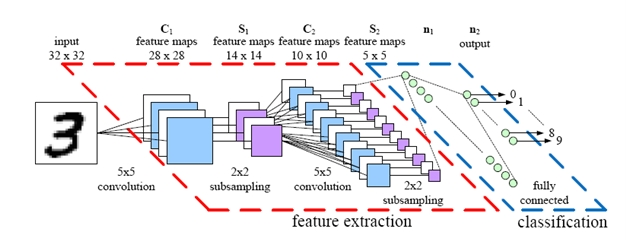
- CNN(Convolutional Neural Network)은 이미지의 **공간 정보를 유지**
- 인접 이미지와의 특징을 효과적으로 인식 하고 강조하는 방식으로 복수의 필터로 이미지의 **특징을 추출(feature extraction)** 과 이미지를 분류기(classifier)로 구성
- 특징 추출 영역은 Filter를 사용하여 공유 파라미터 수를 최소화하면서 이미지의 특징을 찾는 Convolution 레이어와 **특징을 강화하고 모으는 Pooling 레이어**로 구성
- CNN은 Filter의 크기, Stride, Padding과 Pooling 크기로 출력 데이터 크기를 조절하고, 필터의 개수로 출력 데이터 의 채널을 결정
- 각 레이어의 입출력 데이터의 형상 유지
- 필터를 공유 파라미터로 사용하기 때문에,  FCNN 와 비교하여 더 작은 학습 파라미터로 더 높은 인식률을 제공


1. ### locally-connected
    - 특정 픽셀에 대해서 거리가 가까운 pixel은 연관성이 있어서 계산
    - 거리가 먼 pixel은 연관성이 없는 것으로 보고서 계산하지 않는 방식
2. ### Convolutional Filter
    -  이미지가 locally-conntected한 이미지 데이터라는 것을 가정해야 나타나는 개념
    - (현재위치의 1 pixel과 그 가로 세로의 크기만큼의 주변 pixel의 연관 관계를 계산. 가로x세로의 Kernel=Filter를 sliding 하면서 연산)
    - input의 위치와 관계없이, shared weight(특정 영역 추출)를 sliding window하고, 그것을 연산(dot product)하여, 똑 같은 feature라면 위치와 상관없이 해당 feature를 뽑아낼 수 있음
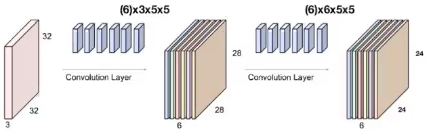

    - Feature Map은 합성곱 계산으로 만들어진 행렬
    - Activation Map은 Feature Map 행렬에 활성 함수를 적용한 결과 즉 Convolution 레이어의 최종 출력 결과가 Activation Map
    
    * Convolutional Layer:여러개의 Convolution Filter를 묶어놓은 것
        - 하나의 Filter당 하나의 feature를 뽑아냄. 그러므로 여러 개의 feature를 뽑아내기 위해서는 여러개의 Filter를 써야한다.

    - 기본적으로 weight처럼 6개의 Convolutional Filter는 서로 다른 랜덤 초기화 필터
    - 각 Convolutional Filter는 6개가 각각 연산해서 각각 6개의 output을 만들고 그 output은 새로운 feature로서 6개가 쌓이는데 output feature라고 부른다.
        - input_filter_size와 convolutional filter의 (input) filter_size는 같아야 함  
        예) input: [32,32,3(input_filter_size)]  
            convolutional filter: [6(output_filter_size),3(input_filter_size),5(Height),5(Width)]         
        - output_filter_size와 convolutional Layer의 filter개수는 같아야 함
        예) output : [5,5,6(output_filter_size)], filter의 갯수는 6개인 경우
        https://nittaku.tistory.com/264

3. ### Padding 
    - Sub sampling
    - Padding을 통해서 Convolution 레이어의 출력 데이터의 사이즈를 조절
  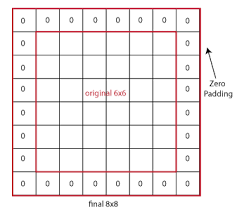
    - zero-padding : 외각을 “0”값으로 둘러싸는 특징으로 부터 인공 신경망이 이미지의 외각을 인식
    -  결과 값을 작아지는 것을 막아서 특징이 유실되는 것을 막음
    - 오버피팅도 방지하게 되는데, 원본 데이타에 0 값을 넣어서 원래의 특징을 희석 시켜 버리고, 이것을 기반으로 머신러닝 모델이 학습값에만 정확하게 맞아 들어가는 오버피팅 현상을 방지함

4. ### Pooling
    - 데이터의 사이즈를 강제로 줄이는 개념. Max Pooling은 Max한 큰값만 챙기고 작은 값을 버림
    - 특징을 나타내는 픽셀은 그렇게 많기 때문에 중요한 pixel만 선별해서 연산
    - 즉, 필요없는 feature를 버려서, 남은 메모리는 다음 Conv Layer를 쌓는데 사용해서 연산을 효율적으로 만듦  
    전체 데이타의 사이즈가 줄어들기 때문에 연산에 들어가는 컴퓨팅 리소스가 적음
    - 데이타의 크기를 줄이면서 소실이 발생하기 때문에, 오버피팅을 방지
    - 학습대상 파라미터가 없음
    - Pooling 레이어를 통과하면 행렬의 크기 감소 & 채널 수 무변
   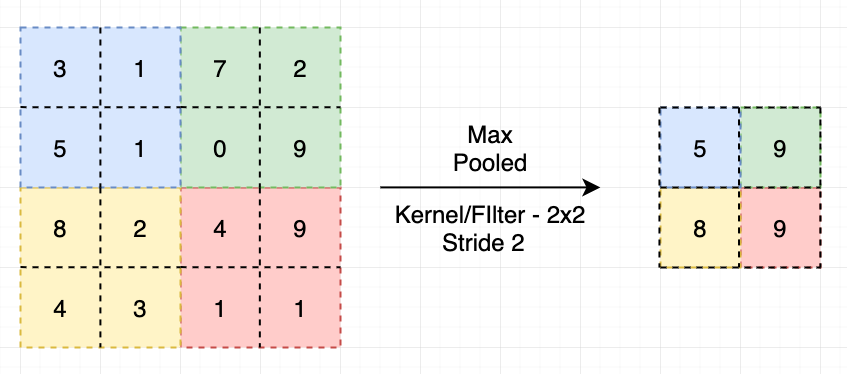  
    
### Max Pooling
    - 실용적인 접근에 있어서 많이 안쓰려고 하는 추세
    - CNN의 Layer는 앞쪽일수록 저차원의 linear한 feature를 뽑아내고, 뒤로 갈수록 고차원의 feature를 뽑아냄 (hierarchy 특성)
  

> empirical (경험적)  
     - 귀납적 특성때문에 증명 불가  
     - 실용성이 더 중요  
     
> cherry picking
       https://namu.wiki/w/%EC%B2%B4%EB%A6%AC%ED%94%BC%ED%82%B9  
     - Yann LeCun Cake Analogy : ML의 분류 강화학습은 체리로 비유하고 비지도학습은 케잌으로 비유  
     - NFL(No Free Lunch) 임에 불구하고 모델 돌리고 나서 좋은 결과만 보여주는 것  
     - GAN(Generative Adversarial Network)을 극찬했으나 이것도 cherry picking 하였고 가능성을 보여주기 위함이었다고 함  
        

최적의 모델 
- 하이퍼파라미터 튜징 GridSearchCV, Keras Tuner로 자동으로 찾음
- 기준 모델을 만들고 Learning curve를 보고 결정



>  과적합 방지 방법
    - cross validaiotn 
    - feature selection
    - dimensionality reduction
    - bagging
    - early stopping
    - regulizer(L1,L2)
    - dropout
    - image에 noise 추가

---
- numpy programming 문제점 
    - GPU 불가
    - mutable
- tensor
    - GPU 지원
    - immutable 
    - functional api
    - 자동미분 Autograd 제공
        - back propagatoin 구현

참고 :https://www.tensorflow.org/tutorials/images/cnn


## CNN구현

In [2]:
import tensorflow as tf

### 데이터셋 준비
1. holdout
2. 데이터 모양 변경
    - 알고리즘에 따라서 데이터 받는게 다름(NFL)
    - CNN 3차원 
    - NN에만 효율적
3. 정규화

## 흑백 이미지

In [3]:
(X_train,y_train),(X_test,y_test) = tf.keras.datasets.mnist.load_data() # holdout
print(X_train.shape)

X_train = X_train.reshape((-1,28,28,1))  # 6만개의 28x28 흑백 이미지
X_test = X_test.reshape((-1,28,28,1))    # 1만개의 28x28 흑백 이미지

X_train, X_test = X_train/255.,X_test/255. #  0~1 사이로 정규화

(60000, 28, 28)


#### 1차원 convolution
- Conv1D
- Convolution1D
    - 자연어처리에서 특징 추출, 신호처리

In [4]:
tf.keras.layers.Conv1D is tf.keras.layers.Convolution1D # 동일

True

In [5]:
tf.keras.layers.Conv2D is tf.keras.layers.Convolution2D # 동일

True

### 2차원 convolution
- 입력 (세로,가로,채널) 의 tensor
    - 방법론에 따라서 데이터 바꿈 
- Conv2D
- Convolution2D
    - args : **filter , kernel_size** , strides, padding data_format: 'valid', 'same', activation,use_bias, kernel_initializer 초기값, regularizer 과적합 방지, constraint 값(W,b) 범위 정함  
    https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D

- 합성곱 층: feature extraction
    - convolution+pooling 짝을 이루는거는 옛날 예시
- Dense 층: classification
### MaxPool2D
- 피라미드 형태로 node 를 늘리면 특징을 더 잘 추출 

In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),  # 3x3 커널 64개
    tf.keras.layers.MaxPool2D((2,2)), 
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 64)                1

In [7]:
# 위와 동일
# model = tf.keras.models.Sequential([
#     tf.keras.Input(shape=(28,28,1)),
#     tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
#     tf.keras.layers.MaxPool2D((2,2)),
#     tf.keras.layers.Conv2D(64,(3,3),activation='relu'),  # 3x3 커널 64개
#     tf.keras.layers.MaxPool2D((2,2)), 
    
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(64,activation='relu'),
#     tf.keras.layers.Dense(10,activation='softmax'),
# ])
# model.summary()

- 연산량이 많아서 FCNN(Fully Connected Neural Network)에 비해서 느림 
- 데이터 자체가 전처리 잘 되어 있어서 정확도가 99%로 높음

In [8]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 18s 4ms/step - loss: 0.1355 - accuracy: 0.9587
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0456 - accuracy: 0.9860
Epoch 3/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0313 - accuracy: 0.9899
Epoch 4/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0238 - accuracy: 0.9923
Epoch 5/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0174 - accuracy: 0.9946


## 색상 이미지
- 3 ~ 4 channels
### cifar10
- 60,000개의 10개의 클래스를 갖는 컬러 이미지(3 channels) ,32x32
- train:test = 6:1

참고 : https://www.tensorflow.org/tutorials/images/cnn

In [9]:
(X_train,y_train),(X_tests,y_test) = tf.keras.datasets.cifar10.load_data() # holdout

# 0 ~ 1사이로 정규화
X_train, X_tests = X_train/255. , X_tests/255.

170498071/170498071 [==============================] - 19s 0us/step


In [10]:
X_train.shape

(50000, 32, 32, 3)

In [11]:
import matplotlib.pyplot as plt

- 배경도 있음
- 다양한 이미지(동물, automobile)
- 다양한 각도

array([9], dtype=uint8)

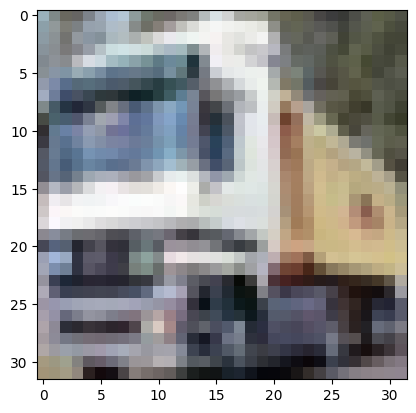

In [12]:
plt.imshow(X_train[1])
y_train[1]  # 9, truck
# airplane										
# automobile										
# bird										
# cat										
# deer										
# dog										
# frog										
# horse										
# ship										
# truck

[6] [9] [9] [4] [1] [1] [2] [7] [8] 

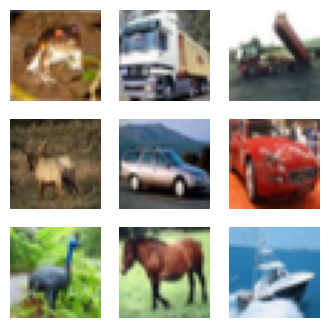

In [13]:
# 여러 동물, 자동차,배 사진 섞여 있음
plt.figure(figsize=(4,4))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis('off')
    print(y_train[i],end=' ')

In [14]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'), 
    tf.keras.layers.MaxPool2D((2,2)), 
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dense_2 (Dense)             (None, 64)               

In [15]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5)  # CPU 약 5분 소요

Epoch 1/5
1563/1563 [==============================] - 11s 7ms/step - loss: 1.4709 - accuracy: 0.4715
Epoch 2/5
1563/1563 [==============================] - 8s 5ms/step - loss: 1.1035 - accuracy: 0.6134
Epoch 3/5
1563/1563 [==============================] - 9s 5ms/step - loss: 0.9692 - accuracy: 0.6607
Epoch 4/5
1563/1563 [==============================] - 11s 7ms/step - loss: 0.8844 - accuracy: 0.6930
Epoch 5/5
1563/1563 [==============================] - 9s 5ms/step - loss: 0.8245 - accuracy: 0.7140


### 성능 향상
1. 합성곱 레이어 늘리기

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'), 
    tf.keras.layers.MaxPool2D((2,2)), 
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'), 
    tf.keras.layers.MaxPool2D((2,2)),     
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),
])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 2, 2, 64)        

In [17]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
model.fit(X_train,y_train,epochs=5)  # CPU 약 6분 소요 , 개선 없음

Epoch 1/5
1563/1563 [==============================] - 11s 6ms/step - loss: 1.5816 - accuracy: 0.4195
Epoch 2/5
1563/1563 [==============================] - 10s 6ms/step - loss: 1.2046 - accuracy: 0.5725
Epoch 3/5
1563/1563 [==============================] - 9s 6ms/step - loss: 1.0510 - accuracy: 0.6303
Epoch 4/5
1563/1563 [==============================] - 8s 5ms/step - loss: 0.9494 - accuracy: 0.6672
Epoch 5/5
1563/1563 [==============================] - 12s 8ms/step - loss: 0.8730 - accuracy: 0.6945


2. epochs를 늘림

In [18]:
# 모델 동일
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'), 
    tf.keras.layers.MaxPool2D((2,2)), 
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'), 
    tf.keras.layers.MaxPool2D((2,2)),     
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),
])
# model.summary()

In [19]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

history = model.fit(X_train,y_train,epochs=15,validation_split=0.2)  # CPU 약 9분 소요

Epoch 1/15
1250/1250 [==============================] - 8s 6ms/step - loss: 1.6080 - accuracy: 0.4103 - val_loss: 1.3703 - val_accuracy: 0.5079
Epoch 2/15
1250/1250 [==============================] - 6s 5ms/step - loss: 1.2213 - accuracy: 0.5641 - val_loss: 1.2104 - val_accuracy: 0.5613
Epoch 3/15
1250/1250 [==============================] - 7s 6ms/step - loss: 1.0777 - accuracy: 0.6227 - val_loss: 1.0530 - val_accuracy: 0.6230
Epoch 4/15
1250/1250 [==============================] - 8s 6ms/step - loss: 0.9808 - accuracy: 0.6575 - val_loss: 1.0112 - val_accuracy: 0.6466
Epoch 5/15
1250/1250 [==============================] - 7s 6ms/step - loss: 0.9059 - accuracy: 0.6834 - val_loss: 0.9335 - val_accuracy: 0.6775
Epoch 6/15
1250/1250 [==============================] - 7s 6ms/step - loss: 0.8463 - accuracy: 0.7041 - val_loss: 0.9390 - val_accuracy: 0.6783
Epoch 7/15
1250/1250 [==============================] - 9s 7ms/step - loss: 0.7913 - accuracy: 0.7238 - val_loss: 0.9667 - val_accuracy:

In [20]:
model.evaluate(X_tests,y_test)

313/313 [==============================] - 1s 4ms/step - loss: 0.9426 - accuracy: 0.7004


[0.9426417946815491, 0.7003999948501587]

<Axes: >

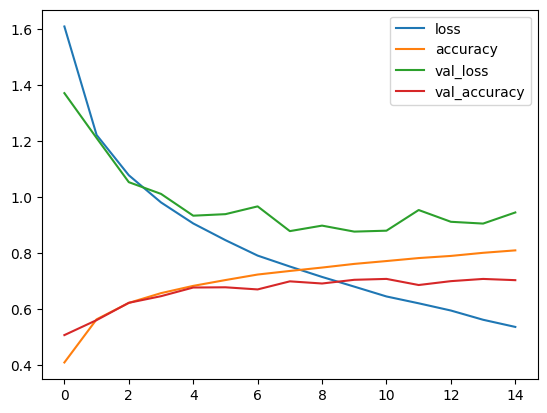

In [21]:
import pandas as pd
pd.DataFrame(history.history).plot.line()

- loss 내려감 학습 잘됨  accuray증가
- val loss는 과적합
    - epochs 8에서 자르고 다른 방법으로 성능을 높임

In [22]:
model=tf.keras.models.Sequential([
    tf.keras.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32,(3,3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)),    
    tf.keras.layers.Conv2D(64,(3,3), activation='relu'),
    tf.keras.layers.MaxPool2D((2, 2)), 
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation ='relu'),
    tf.keras.layers.Dense(10, activation ='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [23]:
history = model.fit(X_train,y_train,epochs=10,validation_split=0.2) # epoch를 줄임

Epoch 1/10
1250/1250 [==============================] - 8s 6ms/step - loss: 1.5795 - accuracy: 0.4242 - val_loss: 1.3827 - val_accuracy: 0.5058
Epoch 2/10
1250/1250 [==============================] - 8s 7ms/step - loss: 1.2398 - accuracy: 0.5561 - val_loss: 1.2180 - val_accuracy: 0.5636
Epoch 3/10
1250/1250 [==============================] - 8s 6ms/step - loss: 1.0962 - accuracy: 0.6110 - val_loss: 1.0797 - val_accuracy: 0.6230
Epoch 4/10
1250/1250 [==============================] - 7s 5ms/step - loss: 0.9997 - accuracy: 0.6474 - val_loss: 1.0278 - val_accuracy: 0.6395
Epoch 5/10
1250/1250 [==============================] - 7s 5ms/step - loss: 0.9266 - accuracy: 0.6778 - val_loss: 0.9806 - val_accuracy: 0.6592
Epoch 6/10
1250/1250 [==============================] - 8s 7ms/step - loss: 0.8679 - accuracy: 0.6945 - val_loss: 0.9637 - val_accuracy: 0.6715
Epoch 7/10
1250/1250 [==============================] - 9s 7ms/step - loss: 0.8108 - accuracy: 0.7154 - val_loss: 0.9858 - val_accuracy:

In [24]:
history = model.fit(X_train,y_train,epochs=5,validation_split=0.2) # history 누적

Epoch 1/5
1250/1250 [==============================] - 8s 6ms/step - loss: 0.6636 - accuracy: 0.7683 - val_loss: 0.9525 - val_accuracy: 0.6894
Epoch 2/5
1250/1250 [==============================] - 7s 5ms/step - loss: 0.6421 - accuracy: 0.7734 - val_loss: 0.9146 - val_accuracy: 0.6943
Epoch 3/5
1250/1250 [==============================] - 8s 6ms/step - loss: 0.6079 - accuracy: 0.7849 - val_loss: 0.9143 - val_accuracy: 0.7030
Epoch 4/5
1250/1250 [==============================] - 11s 9ms/step - loss: 0.5911 - accuracy: 0.7917 - val_loss: 0.9212 - val_accuracy: 0.7006
Epoch 5/5
1250/1250 [==============================] - 7s 5ms/step - loss: 0.5606 - accuracy: 0.8015 - val_loss: 0.9464 - val_accuracy: 0.7016


In [25]:
history.history #가장 최근의 5 history 만 부분적으로 나옴

{'loss': [0.6636266112327576,
  0.6421353220939636,
  0.6078912019729614,
  0.5911347270011902,
  0.5606281161308289],
 'accuracy': [0.7683249711990356,
  0.7734249830245972,
  0.7848749756813049,
  0.7917249798774719,
  0.8015249967575073],
 'val_loss': [0.9525442123413086,
  0.9145753979682922,
  0.9142772555351257,
  0.921177327632904,
  0.946425199508667],
 'val_accuracy': [0.6894000172615051,
  0.6942999958992004,
  0.703000009059906,
  0.7006000280380249,
  0.7016000151634216]}